In [1]:
import pandas as pd
import aif360
from aif360.datasets.german_dataset import default_preprocessing
from aif360.datasets import GermanDataset
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt
from sklearn import feature_selection, preprocessing,linear_model
from sklearn.metrics import mean_squared_error, log_loss, accuracy_score,classification_report, roc_auc_score
import rpy2
from rpy2.robjects.packages import importr
import rpy2.robjects as ro
from rpy2.robjects import numpy2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import default_converter
from projection import sample_projection_posterior, sample_posterior_with_projection_prior, evaluate_posterior_per_budget, evaluate_conjugate_posterior
from metrics import DP_unfairness_TV, DP_unfairness_WD, individual_unfairness, penalisation_function,  parity_gap
from imblearn.under_sampling import RandomUnderSampler
from methods import evaluate_frrm, standardlasso, fairlasso, evaluate_fairfs
from utils import safe_min, safe_argmin, cramers_v
from scipy.stats.contingency import association
import os
from scipy.stats import chi2_contingency

In [2]:
# raw data
# path = os.path.join(os.path.dirname(os.path.abspath(aif360.__file__)),
#                     'data', 'raw', 'german', 'german.data')
#
# # Same column names AIF360 uses internally
# column_names = ['status', 'month', 'credit_history', 'purpose', 'credit_amount',
#                 'savings', 'employment', 'investment_as_income_percentage',
#                 'personal_status', 'other_debtors', 'residence_since',
#                 'property', 'age', 'installment_plans', 'housing',
#                 'number_of_credits', 'skill_level', 'people_liable_for',
#                 'telephone', 'foreign_worker', 'credit']
#
# df_raw = pd.read_csv(path, sep=' ', header=None, names=column_names)
# print(df_raw.head())
# print(df_raw.shape)

In [3]:
# categorical_cols = ['status', 'credit_history', 'purpose', 'savings', 'employment',
#                     'personal_status', 'other_debtors', 'property',
#                     'installment_plans', 'housing', 'skill_level',
#                     'telephone', 'foreign_worker', 'credit']
# df = default_preprocessing(df_raw.copy())
# results = {
#     col: association(pd.crosstab(df[col], df['sex']).to_numpy(), method='cramer')
#     for col in categorical_cols
# }
# cramer_df = (pd.Series(results, name='cramers_v')
#              .sort_values(ascending=False)
#              .to_frame())
# print(cramer_df)

In [4]:
def get_germancredit_data(train=0.8, seed=42, bias_correction=True,
                          categorical_level='variable'):
    """
    categorical_level:
        'variable' -> Cramér's V of the original categorical variable (e.g. 'purpose'),
                      repeated for each of its one-hot columns
        'dummy'    -> Cramér's V of each one-hot column separately (2x2 table, = |phi|)
    """
    dataset = GermanDataset(protected_attribute_names=['sex'], privileged_classes=[['male']])
    dataset_train, dataset_test = dataset.split([train], shuffle=True, seed=seed)

    X_train = pd.DataFrame(dataset_train.features, columns=dataset_train.feature_names)
    X_test  = pd.DataFrame(dataset_test.features,  columns=dataset_test.feature_names)

    y_train = (dataset_train.labels.ravel() == 1.0).astype(int)
    y_test  = (dataset_test.labels.ravel()  == 1.0).astype(int)

    # Drop columns
    cols_to_drop = [c for c in X_train.columns
                    if 'telephone' in c or 'foreign_worker' in c or 'personal_status' in c]
    X_train = X_train.drop(columns=cols_to_drop)
    X_test  = X_test.drop(columns=cols_to_drop)

    # Extract sex
    S_train = X_train.pop('sex').values
    S_test  = X_test.pop('sex').values

    numerical_cols = ['month', 'credit_amount', 'investment_as_income_percentage',
                      'residence_since', 'age', 'number_of_credits', 'people_liable_for']
    categorical_cols = [c for c in X_train.columns if c not in numerical_cols]

    # ---- Association with sex (training data only) ----
    S_series = pd.Series(S_train, index=X_train.index)
    assoc = pd.Series(np.nan, index=X_train.columns, name='assoc_with_sex')

    # Continuous: absolute Pearson correlation (point-biserial, since sex is 0/1)
    for col in numerical_cols:
        assoc[col] = abs(np.corrcoef(X_train[col], S_train)[0, 1])

    # Categorical: Cramér's V
    if categorical_level == 'variable':
        groups = {}
        for c in categorical_cols:                 # AIF360 names dummies 'variable=value'
            groups.setdefault(c.split('=')[0], []).append(c)
        for var, cols in groups.items():
            if len(cols) == 1:                     # binary column, not one-hot encoded
                labels = X_train[cols[0]]
            else:                                  # rebuild the original category
                labels = X_train[cols].idxmax(axis=1)
            assoc[cols] = cramers_v(labels, S_series, bias_correction)
    elif categorical_level == 'dummy':
        for c in categorical_cols:
            assoc[c] = cramers_v(X_train[c], S_series, bias_correction)
    else:
        raise ValueError("categorical_level must be 'variable' or 'dummy'")

    # ---- Scale numerical columns only ----
    scaler = StandardScaler()
    X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
    X_test[numerical_cols]  = scaler.transform(X_test[numerical_cols])

    return (X_train.to_numpy(), y_train, S_train,
            X_test.to_numpy(), y_test, S_test,
            assoc.to_numpy())

In [5]:
X_train, y_train, S_train, X_test, y_test, S_test, assoc = get_germancredit_data(train=0.8, seed=42, bias_correction=False,categorical_level='variable')

In [6]:
assoc

array([0.07092749, 0.06326239, 0.0849508 , 0.05658706, 0.1464375 ,
       0.07578209, 0.18673801, 0.04548818, 0.04548818, 0.04548818,
       0.04548818, 0.12762817, 0.12762817, 0.12762817, 0.12762817,
       0.12762817, 0.15727985, 0.15727985, 0.15727985, 0.15727985,
       0.15727985, 0.15727985, 0.15727985, 0.15727985, 0.15727985,
       0.15727985, 0.05265677, 0.05265677, 0.05265677, 0.05265677,
       0.05265677, 0.19789044, 0.19789044, 0.19789044, 0.19789044,
       0.19789044, 0.0444459 , 0.0444459 , 0.0444459 , 0.07010641,
       0.07010641, 0.07010641, 0.07010641, 0.04967025, 0.04967025,
       0.04967025, 0.22421163, 0.22421163, 0.22421163, 0.09103766,
       0.09103766, 0.09103766, 0.09103766])

In [7]:
weights = np.abs(feature_selection.r_regression(X_train,S_train) )
weights

array([7.09274910e-02, 6.32623910e-02, 8.49507970e-02, 5.65870584e-02,
       1.46437504e-01, 7.57820921e-02, 1.86738010e-01, 2.45673671e-02,
       2.64243859e-02, 1.33882213e-02, 3.97732093e-02, 5.31240099e-04,
       3.24176260e-02, 7.55071037e-02, 1.16102067e-01, 2.49068810e-02,
       2.87917923e-02, 2.78128202e-02, 1.23353334e-03, 1.05921553e-01,
       9.86641427e-03, 2.59042001e-02, 2.88913046e-02, 6.45974739e-02,
       1.91303174e-03, 9.89953313e-02, 4.95306822e-02, 1.21231832e-02,
       3.11394899e-02, 8.19762775e-03, 2.88185477e-02, 4.06933129e-02,
       1.71598413e-01, 2.43137018e-02, 1.65915242e-02, 1.30197935e-01,
       1.73125625e-02, 1.82463327e-02, 4.13647289e-02, 2.12800301e-04,
       3.18829072e-02, 2.28104860e-02, 6.69970842e-02, 3.41166158e-02,
       3.26329666e-02, 4.85653265e-02, 2.20447868e-01, 1.34142630e-01,
       7.62884181e-02, 7.91135724e-02, 2.11182074e-02, 1.01696131e-02,
       4.55526206e-02])

In [8]:
# old preprocessing function
# def get_germancredit_data(train=0.8, seed=42):
#
#     dataset = GermanDataset()
#     dataset_train, dataset_test = dataset.split([0.8], shuffle=True, seed=42)
#
#     X_train = pd.DataFrame(dataset_train.features, columns=dataset_train.feature_names)
#     X_test  = pd.DataFrame(dataset_test.features,  columns=dataset_test.feature_names)
#
#     y_train = (dataset_train.labels.ravel() == 1.0).astype(int)
#     y_test  = (dataset_test.labels.ravel()  == 1.0).astype(int)
#
#     # Drop columns
#     cols_to_drop = [c for c in X_train.columns if 'telephone' in c or 'foreign_worker' in c or 'personal_status' in c]
#     X_train = X_train.drop(columns=cols_to_drop)
#     X_test  = X_test.drop(columns=cols_to_drop)
#
#     # Extract sex
#     S_train = X_train.pop('sex').values
#     S_test  = X_test.pop('sex').values
#
#     # Scale numerical columns only
#     numerical_cols = ['month', 'credit_amount', 'investment_as_income_percentage',
#                       'residence_since', 'age', 'number_of_credits', 'people_liable_for']
#
#     scaler = StandardScaler()
#     X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
#     X_test[numerical_cols]  = scaler.transform(X_test[numerical_cols])
#
#     return X_train.to_numpy(), y_train, S_train, X_test.to_numpy(), y_test, S_test

In [9]:
#X_train, y_train, S_train, X_test, y_test, S_test = get_germancredit_data()

In [10]:
#type(X_train), type(y_train), type(S_train)

In [11]:
# data characteristics
print(X_train.shape, S_train.shape, y_train.shape)
print("Number of samples : ", y_train.shape[0])
print("Number of features : ", X_train.shape[1])
print("Percentage of men : ", np.mean(S_train))

(800, 53) (800,) (800,)
Number of samples :  800
Number of features :  53
Percentage of men :  0.705


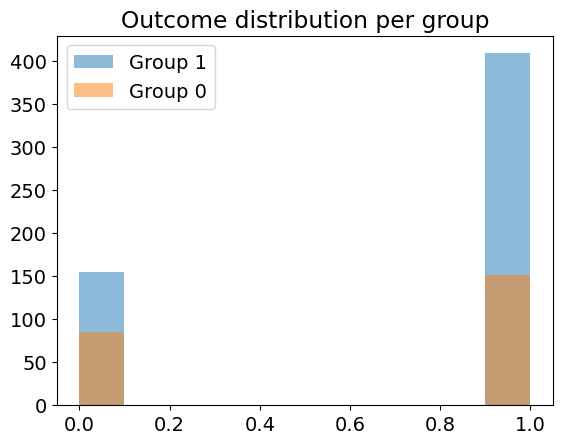

In [12]:
# outcome distribution
plt.rcParams.update({'font.size': 14})
plt.hist(y_train[S_train==1], bins=10, alpha = 0.5, label="Group 1")
plt.hist(y_train[S_train==0], bins=10, alpha = 0.5, label="Group 0")
plt.legend()
plt.title("Outcome distribution per group")
plt.savefig("/Users/deborah/PycharmProjects/FairVariableSelection/figures/germancredit_data.pdf")

In [13]:
# Parity gap
print(np.mean(y_train[S_train==1] == 1), np.mean(y_train[S_train==0] == 1))
np.mean(y_train[S_train==1] == 1) - np.mean(y_train[S_train==0] == 1)

0.725177304964539 0.6398305084745762


0.0853467964899628

In [14]:
# correlation btw S and outcome
corr_y = feature_selection.r_regression(y_train.reshape(-1,1),S_train)
corr_y

array([0.08493431])

In [15]:
# subsample majority class
# rus = RandomUnderSampler(sampling_strategy='not minority', replacement=False, random_state=42)
#
# X_res, S_train = rus.fit_resample(np.concatenate([X_train, y_train.reshape((-1,1))], axis=1), S_train)
# y_train = X_res[:,-1]
# X_train = X_res[:,:-1]
#
# X_res, S_test = rus.fit_resample(np.concatenate([X_test, y_test.reshape((-1,1))], axis=1), S_test)
# y_test = X_res[:,-1]
# X_test = X_res[:,:-1]
#
# pd.Series(S_train).value_counts(), pd.Series(S_train).value_counts()

In [16]:
# Unfairness of features
weights = np.abs(feature_selection.r_regression(X_train,S_train) )
for i in range(X_train.shape[1]):
    wdx = DP_unfairness_WD(X_train[:,i], S_train)
    print(f"Feature {i} :  {wdx:.3f} ")

Feature 0 :  0.159 
Feature 1 :  0.149 
Feature 2 :  0.186 
Feature 3 :  0.183 
Feature 4 :  0.350 
Feature 5 :  0.177 
Feature 6 :  0.409 
Feature 7 :  0.024 
Feature 8 :  0.026 
Feature 9 :  0.007 
Feature 10 :  0.043 
Feature 11 :  0.000 
Feature 12 :  0.016 
Feature 13 :  0.083 
Feature 14 :  0.075 
Feature 15 :  0.025 
Feature 16 :  0.026 
Feature 17 :  0.018 
Feature 18 :  0.000 
Feature 19 :  0.091 
Feature 20 :  0.010 
Feature 21 :  0.006 
Feature 22 :  0.010 
Feature 23 :  0.032 
Feature 24 :  0.000 
Feature 25 :  0.065 
Feature 26 :  0.053 
Feature 27 :  0.008 
Feature 28 :  0.017 
Feature 29 :  0.004 
Feature 30 :  0.025 
Feature 31 :  0.022 
Feature 32 :  0.142 
Feature 33 :  0.025 
Feature 34 :  0.014 
Feature 35 :  0.125 
Feature 36 :  0.011 
Feature 37 :  0.008 
Feature 38 :  0.019 
Feature 39 :  0.000 
Feature 40 :  0.030 
Feature 41 :  0.023 
Feature 42 :  0.053 
Feature 43 :  0.026 
Feature 44 :  0.016 
Feature 45 :  0.042 
Feature 46 :  0.185 
Feature 47 :  0.133 
Fe

### Analysis

In [17]:
# construct approximate ground-truth proba with logistic model
lg_model = LogisticRegression(penalty=None, fit_intercept=True, max_iter=10000)
lg_model.fit(X_train, y_train.reshape(-1,) )
p_train = np.exp(lg_model.predict_log_proba(X_train))[:,1]
p_val = np.exp(lg_model.predict_log_proba(X_test))[:, 1]

In [18]:
log_loss(y_train, p_train), log_loss(y_test, p_val)

(0.45782783452663023, 0.4868758856180638)

#### Standard Lasso Logistic Regression

In [19]:
lasso = standardlasso()
alphas = np.logspace(-1.5, 2.5, num=100, endpoint=True, base=10.0)
lasso_results_train, lasso_results_test = lasso.evaluate(X_train, S_train, y_train, X_test, S_test, y_test, alphas= alphas, #alpha_path,
                                                                 metric="correlation", task="class", plot = False, coeff2=10.0, weights=assoc,
                                                         p_train=p_train, p_val=p_val, coeff=15)

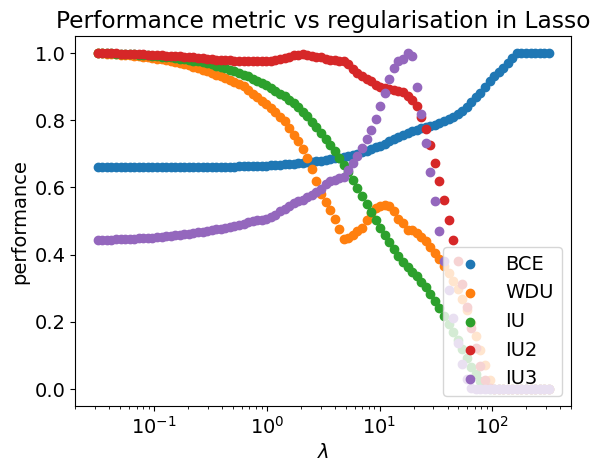

In [20]:
for m in  ["BCE", "WDU", "IU", "IU2", "IU3"]:
    plt.scatter(lasso_results_train["alphas"], lasso_results_train[m] / np.max(lasso_results_train[m]), label=m)
#plt.scatter(lasso_results_train["alphas"], lasso_results_train["Correlation"] / max(lasso_results_train["Correlation"]), label="Correlation")
#plt.hlines(y=results_cald_val["mse"][0], xmin=lamda_grid[0], xmax=lamda_grid[-1])
#plt.yscale("log")
plt.title("Performance metric vs regularisation in Lasso")
plt.xlabel(r"$\lambda$")
plt.ylabel("performance")
plt.xscale("log")
plt.legend(loc="lower right")
plt.savefig("/Users/deborah/PycharmProjects/FairVariableSelection/figures/credit_lasso_class.pdf")

In [21]:
# unconstrained logistic regression
# X_train1 = X_train
# X_test1 = X_test
# #X_train1 = np.concatenate([X_train, S_train.reshape(-1,1)], axis=1)
# #X_test1 = np.concatenate([X_test, S_test.reshape(-1,1)], axis=1)
# model = LogisticRegression(max_iter=1000, C=np.inf, fit_intercept=True)
# model.fit(X_train1, y_train)
# y_train_pred = model.predict_proba(X_train1)[:, 1]
# y_test_pred = model.predict_proba(X_test1)[:, 1]

In [22]:
# perf on train
# print("Accuracy :", accuracy_score(y_train, y_train_pred > 0.5))
# print(classification_report(y_train, y_train_pred > 0.5))
# print("BCE loss :",  log_loss(y_train, y_train_pred))
# print("AUC : ", roc_auc_score(y_train, y_train_pred))
# print("DP unfairness : ", DP_unfairness_WD(y_train_pred, S_train))
# print("Individual unfairness : ", individual_unfairness(y_train, y_train_pred, S_train, task = "class"))
# print("Pen : ", penalisation_function(model.coef_, weights))
# print("Parity gap : ", parity_gap(y_train_pred, S_train))
# pen_truth = penalisation_function(model.coef_, weights)

In [23]:
# lg_results_train = {"acc": accuracy_score(y_train, y_train_pred > 0.5),
#                     "perf":log_loss(y_train, y_train_pred),
#                     "auc": roc_auc_score(y_train, y_train_pred),
#                     "pgap":parity_gap(y_train_pred, S_train),
#                     "WDunfair": DP_unfairness_WD(y_train_pred, S_train),
#                     "Indiv": individual_unfairness(y_train, y_train_pred, S_train, task = "class"),
#                     "pen": penalisation_function(model.coef_, weights)}

In [24]:
# lg_results_test = {"acc": accuracy_score(y_test, y_test_pred > 0.5),
#                     "perf":log_loss(y_test, y_test_pred),
#                     "auc": roc_auc_score(y_test, y_test_pred),
#                     "pgap":parity_gap(y_test_pred, S_test),
#                     "WDunfair": DP_unfairness_WD(y_test_pred, S_test),
#                     "Indiv": individual_unfairness(y_test, y_test_pred, S_test, task = "class"),
#                     "pen": penalisation_function(model.coef_, weights)}

#### Fair methods

#### Fair Lasso

In [25]:
#alphas=np.linspace(0.01,30,200)
alphas_fair_lasso  = np.logspace( -1.5, 6, num=100, endpoint=True, base=10.0)
flasso = fairlasso()
results_train, results_test = flasso.evaluate(X_train, S_train, y_train, X_test, S_test, y_test, alphas=alphas_fair_lasso, task = "class", plot=False, coeff2=10.0, weights=assoc, p_train=p_train, p_val=p_val, coeff=15)

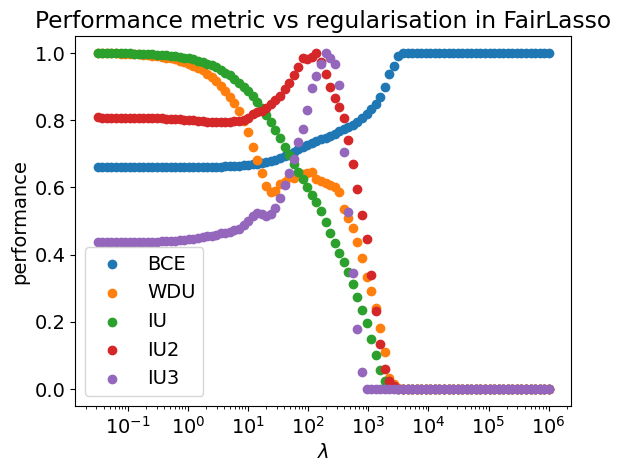

In [26]:
for m in ["BCE", "WDU", "IU",  "IU2", "IU3"]:
    plt.scatter(results_train["alphas"], results_train[m] / np.max( results_train[m]), label=m)
# plt.scatter(results_train["alphas"], results_train["mse"]/ max(results_train["mse"]), label="MSE")
# plt.scatter(results_train["alphas"], results_train["WDunfair"] /  max(results_train["WDunfair"]), label="DP-WD")
# plt.scatter(results_train["alphas"], results_train["Indiv"] / max(results_train["Indiv"]), label="Indiv")
#plt.scatter(results_train["alphas"], results_train["Correlation"], label="Correlation")
#plt.scatter(results_train["alphas"], results_train["Pen"], label="Penalisation")
#plt.hlines(y=results_cald_val["mse"][0], xmin=lamda_grid[0], xmax=lamda_grid[-1])
plt.title("Performance metric vs regularisation in FairLasso")
plt.xlabel(r"$\lambda$")
plt.ylabel("performance")
plt.xscale("log")
plt.legend()
plt.savefig("/Users/deborah/PycharmProjects/FairVariableSelection/figures/credit_fairlasso.pdf")

#### FFS

In [27]:
alphas = np.logspace(-2, 1., num=30, endpoint=True, base=10.0)
ffs_test = evaluate_fairfs(X_train, S_train, y_train, X_test, S_test, y_test, alphas=alphas,  unfairness_metrics=["statistical_parity"])

statistical_parity | weight 0.01 | unfairness=0.050  log_loss=0.490  auc=0.789 | features: x0;x1;x2;x5;x7;x10;x12;x15;x16;x17;x18;x23;x26;x30;x34;x35;x36;x38;x39;x45;x46
statistical_parity | weight 0.01268961003167922 | unfairness=0.050  log_loss=0.490  auc=0.789 | features: x0;x1;x2;x5;x7;x10;x12;x15;x16;x17;x18;x23;x26;x30;x34;x35;x36;x38;x39;x45;x46
statistical_parity | weight 0.01610262027560939 | unfairness=0.090  log_loss=0.513  auc=0.767 | features: x0;x1;x2;x5;x8;x10;x15;x16;x17;x18;x23;x30;x34;x35;x37;x39;x45;x46
statistical_parity | weight 0.020433597178569417 | unfairness=0.090  log_loss=0.513  auc=0.767 | features: x0;x1;x2;x5;x8;x10;x15;x16;x17;x18;x23;x30;x34;x35;x37;x39;x45;x46
statistical_parity | weight 0.02592943797404667 | unfairness=0.109  log_loss=0.510  auc=0.768 | features: x0;x1;x2;x5;x8;x10;x15;x16;x17;x18;x23;x30;x34;x36;x37;x40;x45;x46
statistical_parity | weight 0.03290344562312668 | unfairness=0.109  log_loss=0.510  auc=0.768 | features: x0;x1;x2;x5;x8;x10;

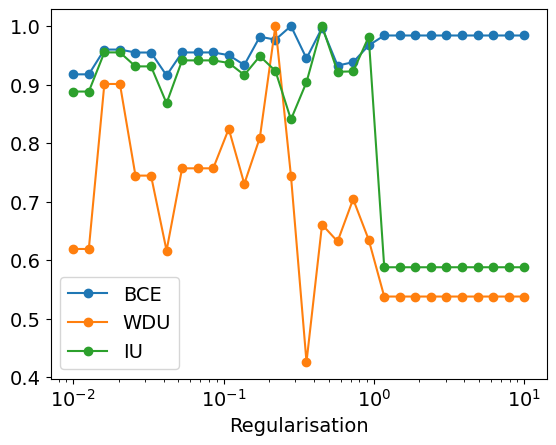

In [28]:
budget=ffs_test["alphas"]
for m in ["BCE", "WDU", "IU"]:
    plt.plot(budget, ffs_test[m]/ max(ffs_test[m]), label=m, marker="o")
plt.xlabel("Regularisation")
plt.xscale("log")
plt.legend()

#### FRRM

In [29]:
budget = np.logspace(-4, 0., num=50, endpoint=True, base=10.0)
frrm_train, frrm_test = evaluate_frrm( X_train,  y_train, S_train, X_test, y_test, S_test, budget=budget, task="class", metric="correlation", coeff2=10.0,p_train=p_train, p_val=p_val)

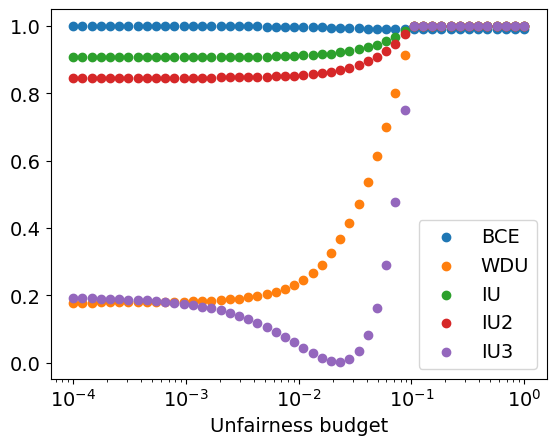

In [30]:
budget=frrm_train["budget"]
for m in ["BCE", "WDU", "IU", "IU2", "IU3"]:
    plt.scatter(budget, frrm_train[m] / np.max(frrm_train[m]), label=m)
plt.xlabel("Unfairness budget")
plt.xscale("log")
plt.legend()

In [31]:
def pareto_plot(m1,m2, fair_lasso_results, lasso_results, frrm_results = None, ffs_results = None, cald_results = None, fp_results = None, pp_results = None, sp_results = None, save_fig=None, normalise = False):

    if normalise:
        max_1 = max( max(lasso_results[m1]), max(fair_lasso_results[m1]), max(frrm_results[m1]))
        max_2 = max( max(lasso_results[m2]), max(fair_lasso_results[m2]), max(frrm_results[m2]))
    else:
        max_1, max_2 = 1.0,1.0

    fig, ax = plt.subplots()
    ax.plot(  lasso_results[m1]/max_1, lasso_results[m2]/max_2, label="Lasso", marker = "o", color="k", ms=10)

    ax.plot( fair_lasso_results[m1]/max_1,  fair_lasso_results[m2]/max_2, label="Fair Lasso", marker = "o", color='tab:blue', ms=10)

    if cald_results is not None:
        ax.plot(  cald_results[m1]/max_1, cald_results[m2]/max_2, label="MD", marker = "o", color="tab:orange")

    if frrm_results is not None:
        ax.plot( frrm_results[m1]/max_1,  frrm_results[m2]/max_2, label="FRRM", marker = "v", color="tab:red", ms=10)

    if ffs_results is not None:
        ax.plot( ffs_results[m1]/max_1,  ffs_results[m2]/max_2, label="FFS", marker = "v", color="tab:pink", ms=10)


    if fp_results is not None:
        avg_1 = np.mean(fp_results[m1], axis=1)
        avg_2 = np.mean(fp_results[m2], axis=1)
        ax.plot(  avg_1 / max_1, avg_2 /max_2, label="PP", marker="v", color='tab:brown')

    if pp_results is not None:
        avg_1 = np.mean(pp_results[m1], axis=1)
        avg_2 = np.mean(pp_results[m2], axis=1)
        ax.plot(  avg_1 / max_1, avg_2 /max_2, label="FP", marker = "P", color='tab:green')

    if sp_results is not None:
        avg_1 = np.mean(sp_results[m1], axis=1)
        avg_2 = np.mean(sp_results[m2], axis=1)
        ax.plot(  avg_1 / max_1, avg_2 /max_2, label="SP", marker = "v", color="k")

    #plt.yscale("log")
    if m1 == "IU2":
        plt.xlabel("IU")
    else:
        plt.xlabel(m1)
    if m2 == "IU2":
        plt.ylabel("IU")
    else:
        plt.ylabel(m2)
    plt.legend()
    if save_fig is not None:
        plt.savefig("/Users/deborah/PycharmProjects/FairVariableSelection/figures/" + save_fig)

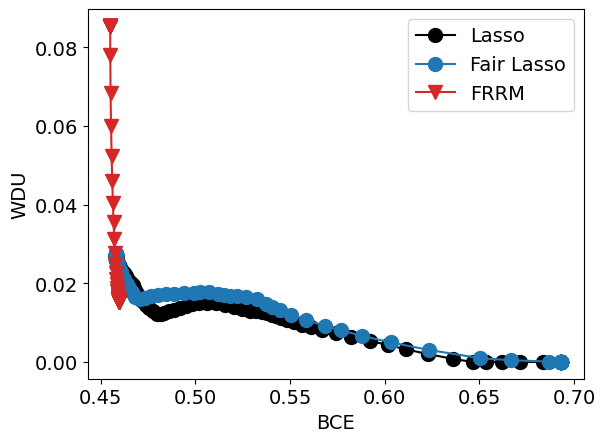

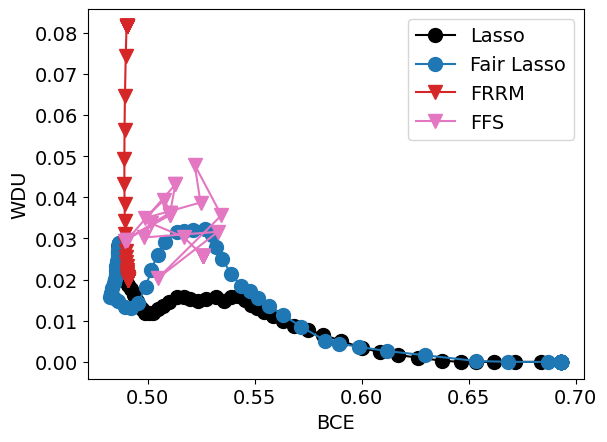

In [32]:
m1,m2 =  "BCE", "WDU"
pareto_plot(m1,m2, results_train, lasso_results_train, frrm_train, save_fig="credit_comp_train_1")
pareto_plot(m1,m2, results_test, lasso_results_test, frrm_test, ffs_results=ffs_test, save_fig="credit_comp_test_1")

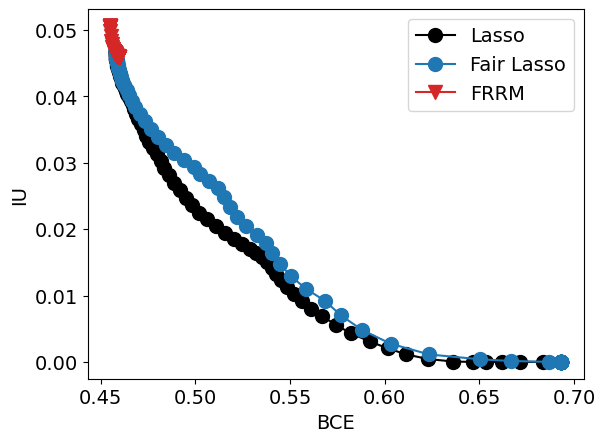

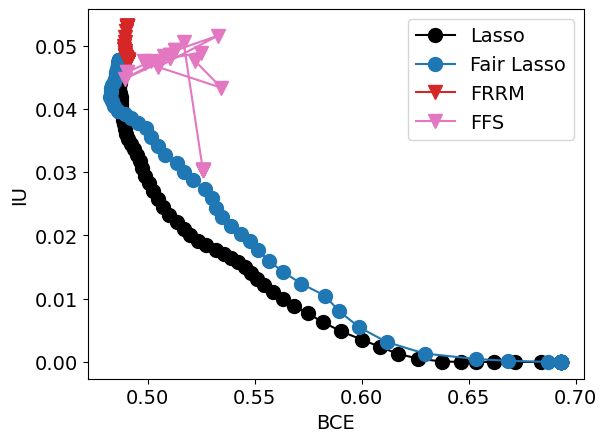

In [33]:
m2,m1 = "IU", "BCE"
pareto_plot(m1,m2, results_train, lasso_results_train, frrm_train, save_fig="credit_comp_train_2")
pareto_plot(m1,m2, results_test, lasso_results_test, frrm_test, ffs_results=ffs_test,save_fig="credit_comp_test_2")

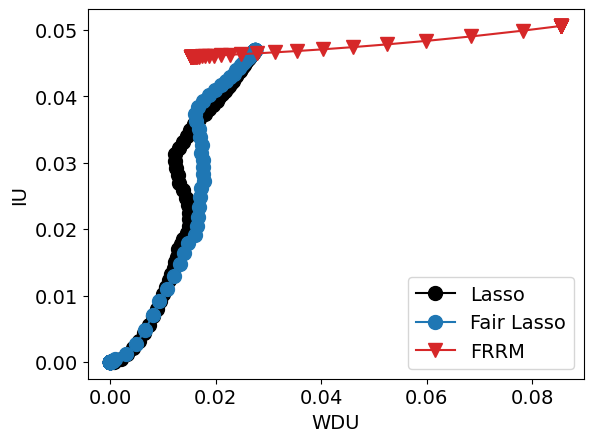

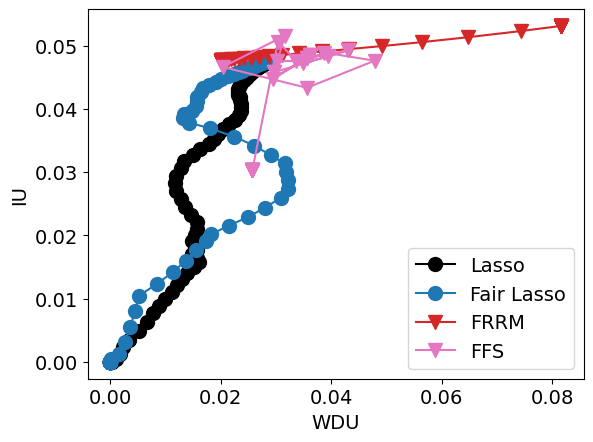

In [34]:
m1,m2 = "WDU", "IU"
pareto_plot(m1,m2, results_train, lasso_results_train, frrm_train, save_fig="credit_comp_train_3")
pareto_plot(m1,m2, results_test, lasso_results_test, frrm_test, ffs_results=ffs_test, save_fig="credit_comp_test_3")

#### fair posteriors

In [35]:
a, b = 1, 1 # hyperparameter of gamma prior
beta_var = 1.0
radius  = np.logspace(-4, 1.0, num=50, endpoint=True, base=10.0)
projection_post, conjugate_post = sample_projection_posterior(X_train, y_train, S_train, a=a, b=b, beta_var=beta_var, task="class", radius=radius, intercept=True, num_samples = 2000, weights=assoc)

sample: 100%|██████████| 3000/3000 [00:02<00:00, 1060.96it/s, 63 steps of size 6.74e-02. acc. prob=0.93] 


In [36]:
fp_results_train, fp_results_test = evaluate_posterior_per_budget(projection_post, X_train, S_train, y_train, X_test, S_test, y_test, task="class", p_train=p_train, p_val=p_val)
cp_results_train, cp_results_test = evaluate_conjugate_posterior(conjugate_post, X_train, S_train, y_train, X_test, S_test, y_test, task="class", weights=projection_post["weights"],
                                                                 p_train=p_train, p_val=p_val)

In [37]:
proj_prior = sample_posterior_with_projection_prior(X_train, y_train, S_train, a=a, b=b, beta_var=beta_var, radius=radius, intercept=True, num_samples = 2000, task = "class", weights=assoc)

sample: 100%|██████████| 3000/3000 [00:04<00:00, 672.82it/s, 127 steps of size 6.96e-02. acc. prob=0.93]


In [38]:
pp_results_train,pp_results_test = evaluate_posterior_per_budget(proj_prior, X_train, S_train, y_train, X_test, S_test, y_test, task = "class",p_train=p_train, p_val=p_val)

In [39]:
radius  = np.logspace(-2., 2.0, num=50, endpoint=True, base=10.0)
sparse_prior = sample_posterior_with_projection_prior(X_train, y_train, S_train, a=a, b=b, beta_var=beta_var, radius=radius, intercept=True, num_samples = 2000, task = "class", metric = None)

sample: 100%|██████████| 3000/3000 [00:04<00:00, 621.96it/s, 127 steps of size 6.96e-02. acc. prob=0.93]


In [40]:
sp_results_train,sp_results_test = evaluate_posterior_per_budget(sparse_prior, X_train, S_train, y_train, X_test, S_test, y_test,
                                                                 #weights = projection_post["weights"],
                                                                 task = "class", p_train=p_train, p_val=p_val)

In [41]:
def posterior_risk_plot(fp_results, cp_results = None, savefig = None, normalise = True):

    colors = ["C0", "C1", "C2"]

    plt.figure(figsize=(8, 5))

    for i,m in enumerate(["BCE","WDU", "IU"]):

        lower = np.percentile(fp_results[m], 2.5, axis=1)
        upper = np.percentile(fp_results[m], 97.5, axis=1)
        median = np.percentile(fp_results[m], 50, axis=1)
        avg = np.mean(fp_results[m], axis=1)

        if normalise:
            cp_mean_value = max( np.max(fp_results[m]), np.max(cp_results[m]))
        else:
            cp_mean_value = 1.0
        #cp_mean_value = cp_results_train["pmean"][i]

        plt.fill_between(
            fp_results["budget"],
            lower / cp_mean_value,
            upper / cp_mean_value,
            alpha=0.3,
            color=colors[i]
        )

        plt.plot(fp_results["budget"], avg / cp_mean_value, label=m, linewidth=2, color=colors[i])

        if cp_results is not None:
            lower = np.percentile(cp_results[m], 2.5)
            upper = np.percentile(cp_results[m], 97.5)
            plt.fill_between(
                fp_results["budget"],
                lower  / cp_mean_value * np.ones(len(fp_results["budget"])),
                upper / cp_mean_value * np.ones(len(fp_results["budget"])),
                alpha=0.2,
                color=colors[i]
            )
            plt.hlines(y= np.mean(cp_results[m]) / cp_mean_value, xmin=0.00, xmax=max(fp_results["budget"]), linestyles="dotted", color=colors[i])

    plt.xlabel("Unfairness budget")
    plt.ylabel("Metric")
    plt.xscale("log")
    plt.legend()
    if savefig is not None:
        plt.savefig("/Users/deborah/PycharmProjects/FairVariableSelection/figures/" + savefig)

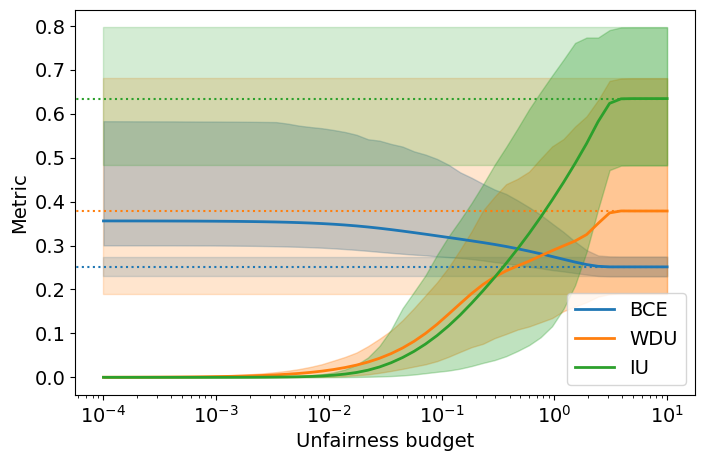

In [42]:
#posterior_risk_plot(fp_results_train, cp_results_train) #, savefig = "community_pp_train")
posterior_risk_plot(fp_results_test, cp_results_test) #, savefig = "community_pp_test")

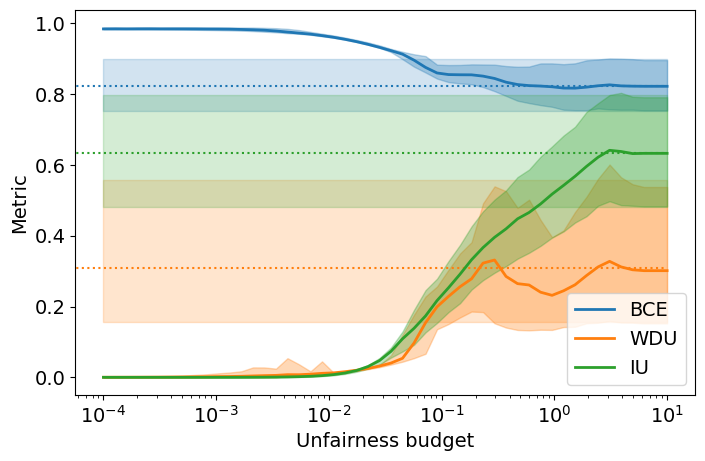

In [43]:
#posterior_risk_plot(pp_results_train, cp_results_train) #, savefig = "community_ppp_train")
posterior_risk_plot(pp_results_test, cp_results_test) #, savefig = "community_ppp_test")

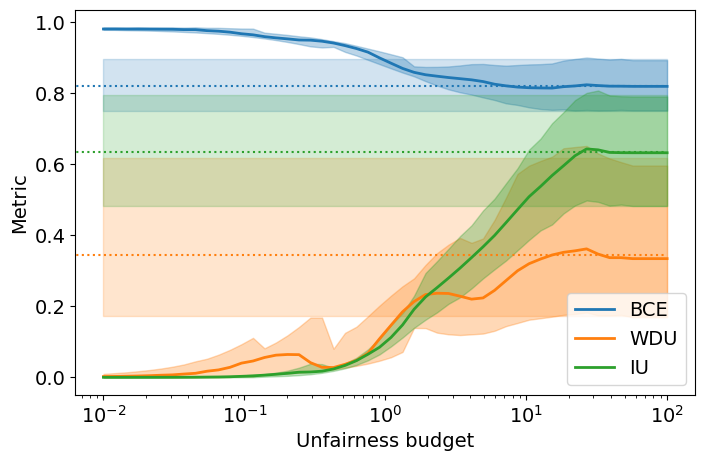

In [44]:
#posterior_risk_plot(sp_results_train, cp_results_train, savefig = "community_sp_train")
posterior_risk_plot(sp_results_test, cp_results_test) # savefig = "community_sp_test")

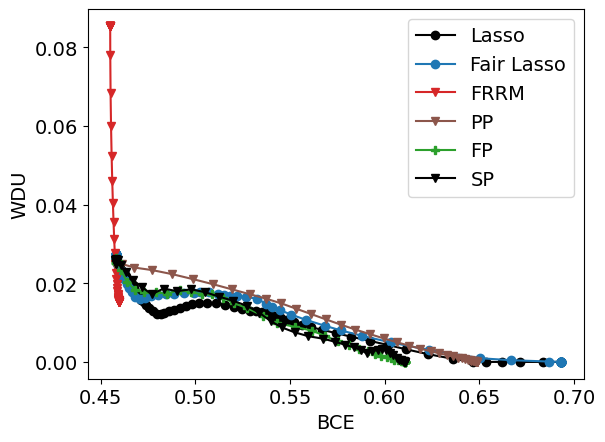

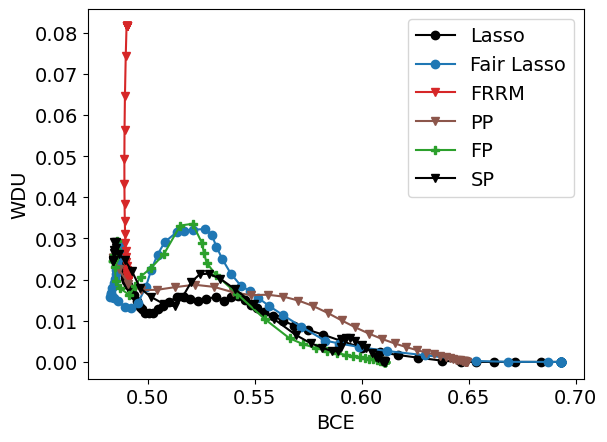

In [45]:
m2,m1 = "WDU", "BCE"
pareto_plot(m1,m2, results_train, lasso_results_train, frrm_train, fp_results=fp_results_train["PP"], pp_results=pp_results_train["PP"], sp_results=sp_results_train["PP"],
             save_fig="credit_comp_all_train_1")
pareto_plot(m1,m2, results_test, lasso_results_test, frrm_test, fp_results=fp_results_test["PP"], pp_results=pp_results_test["PP"], sp_results=sp_results_test["PP"],
save_fig="credit_comp_all_test_1")

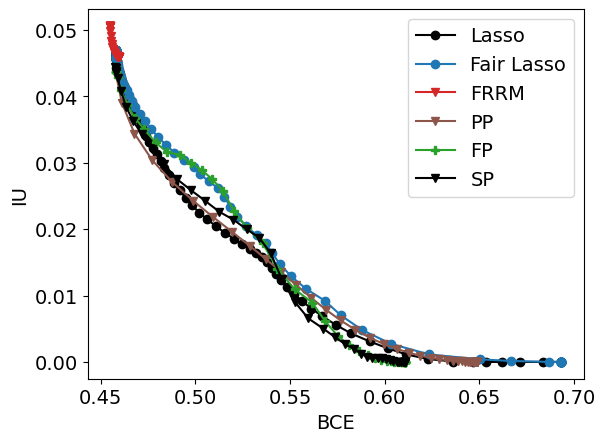

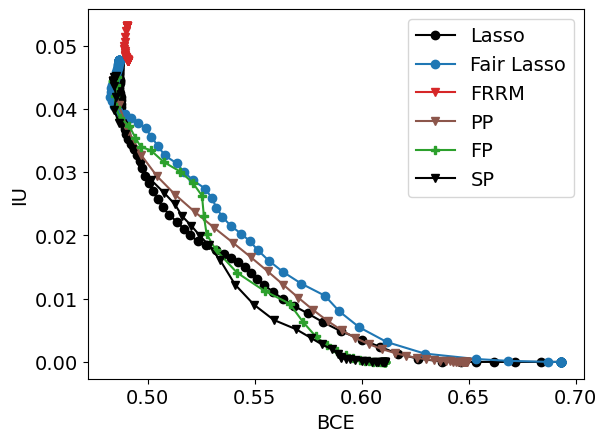

In [46]:
m2,m1 = "IU", "BCE"
pareto_plot(m1,m2, results_train, lasso_results_train, frrm_train, fp_results=fp_results_train["PP"], pp_results=pp_results_train["PP"], sp_results=sp_results_train["PP"],
             save_fig="credit_comp_all_train_2")
pareto_plot(m1,m2, results_test, lasso_results_test, frrm_test, fp_results=fp_results_test["PP"], pp_results=pp_results_test["PP"], sp_results=sp_results_test["PP"],
save_fig="credit_comp_all_test_2")

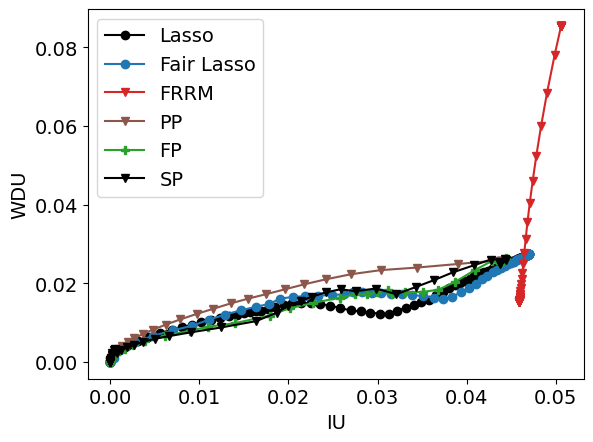

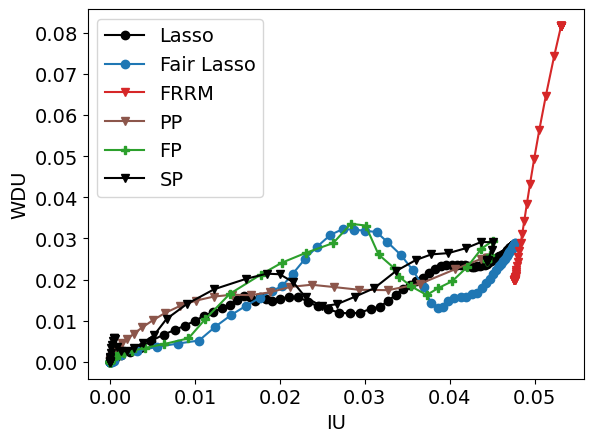

In [47]:
m2,m1 = "WDU", "IU"
pareto_plot(m1,m2, results_train, lasso_results_train, frrm_train, fp_results=fp_results_train["PP"], pp_results=pp_results_train["PP"], sp_results=sp_results_train["PP"],
             save_fig="credit_comp_all_train_3")
pareto_plot(m1,m2, results_test, lasso_results_test, frrm_test, fp_results=fp_results_test["PP"], pp_results=pp_results_test["PP"], sp_results=sp_results_test["PP"],
save_fig="credit_comp_all_test_3")

In [48]:
def safe_max(arr):
    return np.max(arr) if len(arr) > 0 else np.nan

def safe_argmax(arr):
    return np.argmax(arr) if len(arr) > 0 else np.nan

{'FP': {'BCE': [0.5662641252961946, 0.5546651463203794, 0.4835722879804203]}, 'PP': {'BCE': [0.6033846919217666, 0.5704436887649332, 0.48386472868765884]}, 'Fair Lasso': {'BCE': [0.5827985450822483, 0.4862211031482138, 0.48248034200647716]}, 'SP': {'BCE': [0.5693085639586224, 0.5076743059394431, 0.4835722879804203]}, 'Lasso': {'BCE': [0.5747342419517658, 0.49514710465686435, 0.48662508082506034]}, 'FRRM': {'BCE': [nan, nan, 0.4895927830756892]}}


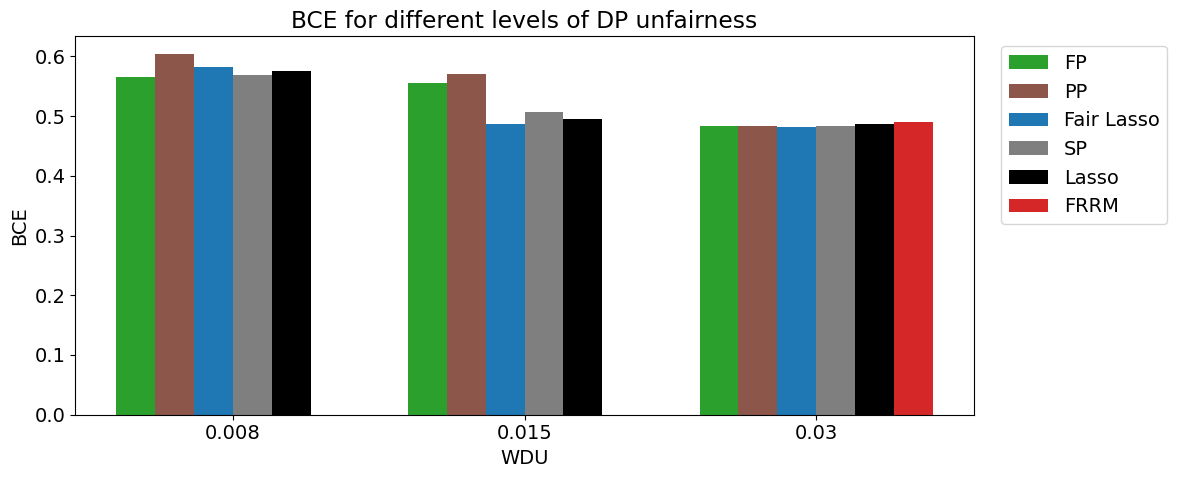

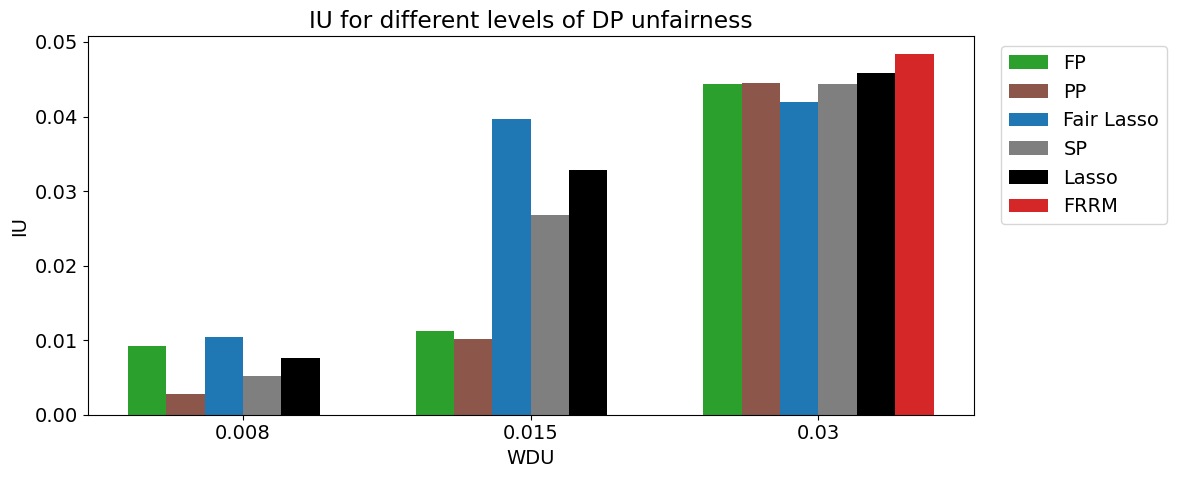

In [49]:
# levels of unfairness

l1 = 0.008
l2 = 0.015
l3 = 0.03

comp = { "FP" : {}, "PP": {} , "Fair Lasso" : {}, "SP":{}, "Lasso" : {}, "FRRM": {} }

# projected posterior
fp_avg_wdu = fp_results_test["PP"]["WDU"] #np.median(fp_results_test["WDU"], axis=1)
fp_avg_mse = fp_results_test["PP"]["BCE"] #np.median(fp_results_test["BCE"], axis=1)
fp_avg_iu =  fp_results_test["PP"]["IU"] #np.median(fp_results_test["IU"], axis=1)

# projected prior
pp_avg_wdu = pp_results_test["PP"]["WDU"] # np.mean(pp_results_test["WDU"], axis=1)
pp_avg_mse = pp_results_test["PP"]["BCE"] # np.mean(pp_results_test["BCE"], axis=1)
pp_avg_iu =  pp_results_test["PP"]["IU"]  #np.mean(pp_results_test["IU"], axis=1)

# sparse posterior
sp_avg_wdu = sp_results_test["PP"]["WDU"] #np.mean(sp_results_test["WDU"], axis=1)
sp_avg_mse = sp_results_test["PP"]["BCE"] # np.mean(sp_results_test["BCE"], axis=1)
sp_avg_iu =  sp_results_test["PP"]["IU"] #np.mean(sp_results_test["IU"], axis=1)


idx_lasso = [np.argmin(lasso_results_test["BCE"][lasso_results_test["WDU"] <= l]) for l in [l1,l2,l3] ]
idx_flasso = [np.argmin(results_test["BCE"][results_test["WDU"] <= l]) for l in [l1,l2,l3] ]
idx_frrm = [safe_argmin(frrm_test["BCE"][frrm_test["WDU"] <= l]) for l in [l1,l2,l3] ]
idx_pp = [np.argmin(fp_avg_mse[fp_avg_wdu <= l]) for l in [l1,l2,l3] ]
idx_ppp = [np.argmin(pp_avg_mse[pp_avg_wdu <= l]) for l in [l1,l2,l3] ]
idx_sp = [np.argmin(sp_avg_mse[sp_avg_wdu <= l]) for l in [l1,l2,l3] ]

#print(idx_lasso)

err = {"FP": {}, "PP":{}, "SP":{}}
err["PP"]["BCE"] = np.transpose([ [np.percentile(fp_results_test["BCE"][i], 5), np.percentile(fp_results_test["BCE"][i], 95)] for i in idx_pp])
err["PP"]["IU"]= np.transpose([ [np.percentile(fp_results_test["IU"][i], 5), np.percentile(fp_results_test["IU"][i], 95)] for i in idx_pp])
err["FP"]["BCE"] = np.transpose([ [np.percentile(pp_results_test["BCE"][i], 5), np.percentile(pp_results_test["BCE"][i], 95)] for i in idx_ppp])
err["FP"]["IU"]= np.transpose([ [np.percentile(pp_results_test["IU"][i], 5), np.percentile(pp_results_test["IU"][i], 95)] for i in idx_ppp])
err["SP"]["BCE"] = np.transpose([ [np.percentile(sp_results_test["BCE"][i], 5), np.percentile(sp_results_test["BCE"][i], 95)] for i in idx_ppp])
err["SP"]["IU"]= np.transpose([ [np.percentile(sp_results_test["IU"][i], 5), np.percentile(sp_results_test["IU"][i], 95)] for i in idx_ppp])


comp["Lasso"]["BCE"] = [ np.min(lasso_results_test["BCE"][lasso_results_test["WDU"] <= l]) for l in [l1,l2,l3] ]
comp["Fair Lasso"]["BCE"] = [ np.min(results_test["BCE"][results_test["WDU"] <= l]) for l in [l1,l2,l3] ]
comp["FRRM"]["BCE"] = [ safe_min(frrm_test["BCE"][frrm_test["WDU"] <= l]) for l in [l1,l2,l3] ]
comp["PP"]["BCE"] = [ np.min(fp_avg_mse[fp_avg_wdu <= l]) for l in [l1,l2,l3] ]
comp["FP"]["BCE"] = [ np.min(pp_avg_mse[pp_avg_wdu <= l]) for l in [l1,l2,l3] ]
comp["SP"]["BCE"] = [ np.min(sp_avg_mse[sp_avg_wdu <= l]) for l in [l1,l2,l3] ]


print(comp)

comp["Lasso"]["IU"] = [lasso_results_test["IU"][lasso_results_test["WDU"] <= l][idx_lasso[i]] for i,l in enumerate([l1,l2,l3]) ]
comp["Fair Lasso"]["IU"] = [ results_test["IU"][results_test["WDU"] <= l][idx_flasso[i]] for i,l in enumerate([l1,l2,l3]) ]
comp["FRRM"]["IU"] = [ frrm_test["IU"][frrm_test["WDU"] <= l][idx_frrm[i]] if idx_frrm[i] is not np.nan else np.nan for i,l in enumerate([l1,l2,l3])]
comp["PP"]["IU"] = [fp_avg_iu[fp_avg_wdu <= l][idx_pp[i]] for i,l in enumerate([l1,l2,l3]) ]
comp["FP"]["IU"] = [pp_avg_iu[pp_avg_wdu <= l][idx_ppp[i]] for i,l in enumerate([l1,l2,l3]) ]
comp["SP"]["IU"] = [sp_avg_iu[sp_avg_wdu <= l][idx_sp[i]] for i,l in enumerate([l1,l2,l3]) ]


for m in ["BCE", "IU"]:
    fig, ax = plt.subplots(figsize=(12, 5))

    methods = list(comp.keys())
    n_methods = len(methods)
    n_metrics = len(comp["Lasso"][m])

    colors=[ "tab:green", "tab:brown", "tab:blue", "tab:grey", "k", "tab:red"]

    #colors = plt.cm.tab10.colors

    x = np.arange(n_metrics)
    width = 0.8 / n_methods

    for i, method in enumerate(list(comp.keys())):
        offset = (i - n_methods / 2 + 0.5) * width
        # if method in ["PPP", "PP", "SP"]:
        #     ax.bar(x + offset, comp[method][m], width, label=method, color =colors[i], yerr = err[method][m])
        # else:
        #if method != "PP":
        ax.bar(x + offset, comp[method][m], width, label=method, color =colors[i])

    ax.set_xticks(x)
    ax.set_xticklabels([l1,l2,l3])
    ax.set_ylabel(m)
    ax.set_title(f'{m} for different levels of DP unfairness')
    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    #ax.set_ylim(0, 1)
    plt.xlabel("WDU")
    plt.tight_layout()
    plt.savefig(f"/Users/deborah/PycharmProjects/FairVariableSelection/figures/credit_data_3budgets_WDU_{m}.pdf", bbox_inches="tight")

{'FP': {'BCE': [0.5662641252961946, 0.5209761362789106, 0.4835722879804203]}, 'PP': {'BCE': [0.577326860139245, 0.5043474958591485, 0.48386472868765884]}, 'Fair Lasso': {'BCE': [0.589538600562, 0.5212318204758035, 0.48248034200647716]}, 'SP': {'BCE': [0.5496506281270205, 0.5014938018881092, 0.4835722879804203]}, 'Lasso': {'BCE': [0.5632021844193181, 0.4986695822516707, 0.48662508082506034]}, 'FRRM': {'BCE': [nan, nan, 0.48910277905126065]}}


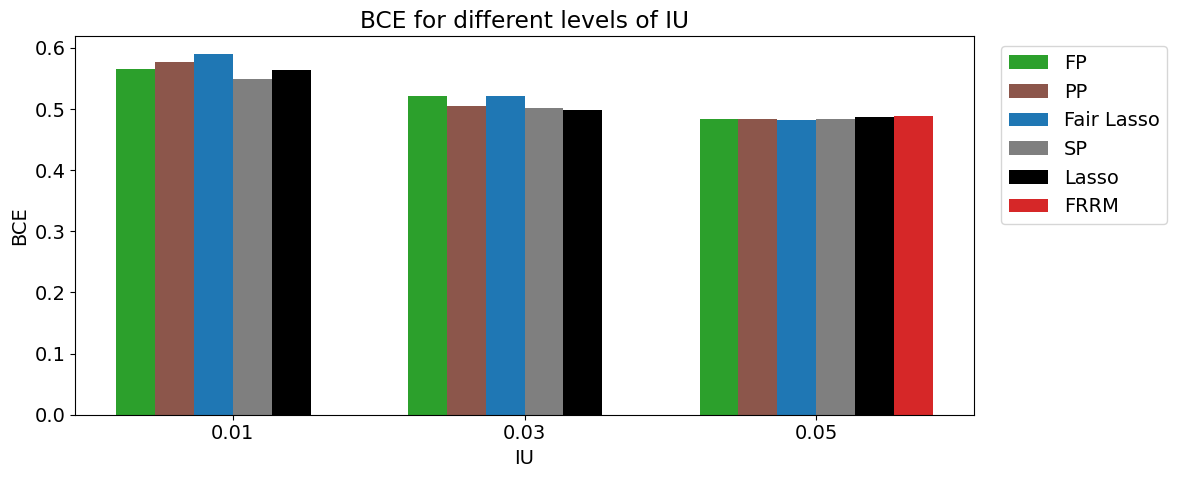

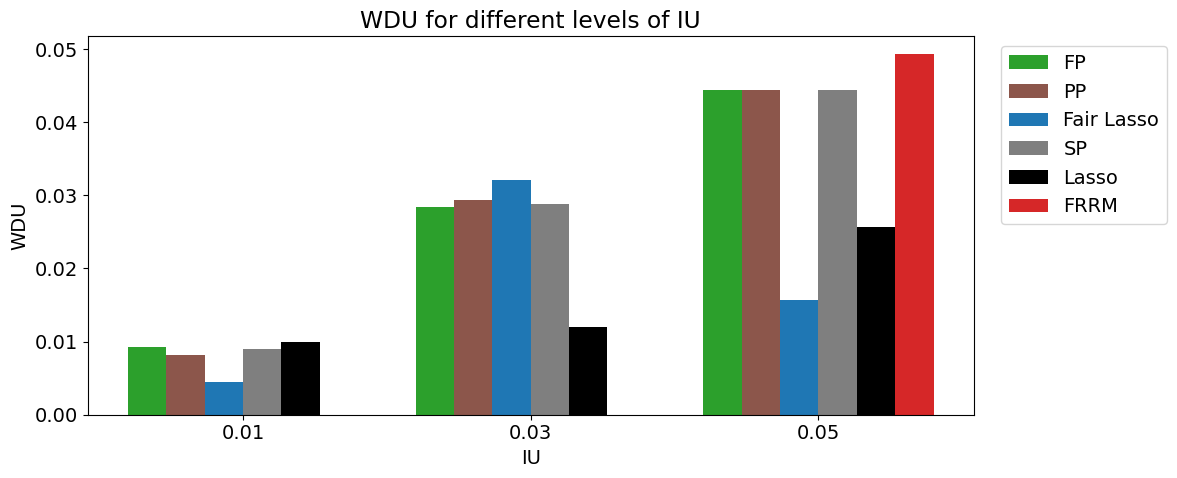

In [50]:
# levels of unfairness

l1 = 0.01
l2 = 0.03
l3 = 0.05

comp = { "FP" : {}, "PP": {} , "Fair Lasso" : {},  "SP":{}, "Lasso" : {}, "FRRM": {}}

# projected posterior
fp_avg_wdu = fp_results_test["PP"]["WDU"] #np.median(fp_results_test["WDU"], axis=1)
fp_avg_mse = fp_results_test["PP"]["BCE"] #np.median(fp_results_test["BCE"], axis=1)
fp_avg_iu =  fp_results_test["PP"]["IU"] #np.median(fp_results_test["IU"], axis=1)

# projected prior
pp_avg_wdu = pp_results_test["PP"]["WDU"] # np.mean(pp_results_test["WDU"], axis=1)
pp_avg_mse = pp_results_test["PP"]["BCE"] # np.mean(pp_results_test["BCE"], axis=1)
pp_avg_iu =  pp_results_test["PP"]["IU"]  #np.mean(pp_results_test["IU"], axis=1)

# sparse posterior
sp_avg_wdu = sp_results_test["PP"]["WDU"] #np.mean(sp_results_test["WDU"], axis=1)
sp_avg_mse = sp_results_test["PP"]["BCE"] # np.mean(sp_results_test["BCE"], axis=1)
sp_avg_iu =  sp_results_test["PP"]["IU"] #np.mean(sp_results_test["IU"], axis=1)


idx_lasso = [np.argmin(lasso_results_test["BCE"][lasso_results_test["IU"] <= l]) for l in [l1,l2,l3] ]
idx_flasso = [np.argmin(results_test["BCE"][results_test["IU"] <= l]) for l in [l1,l2,l3] ]
idx_frrm = [safe_argmin(frrm_test["BCE"][frrm_test["IU"] <= l]) for l in [l1,l2,l3] ]
idx_pp = [np.argmin(fp_avg_mse[fp_avg_iu <= l]) for l in [l1,l2,l3] ]
idx_ppp = [np.argmin(pp_avg_mse[pp_avg_iu <= l]) for l in [l1,l2,l3] ]
idx_sp = [np.argmin(sp_avg_mse[sp_avg_iu <= l]) for l in [l1,l2,l3] ]

#print(idx_lasso)

err = {"PP": {}, "FP":{}, "SP":{}}
err["PP"]["BCE"] = np.transpose([ [np.percentile(fp_results_test["BCE"][i], 5), np.percentile(fp_results_test["BCE"][i], 95)] for i in idx_pp])
err["PP"]["IU"]= np.transpose([ [np.percentile(fp_results_test["IU"][i], 5), np.percentile(fp_results_test["IU"][i], 95)] for i in idx_pp])
err["FP"]["BCE"] = np.transpose([ [np.percentile(pp_results_test["BCE"][i], 5), np.percentile(pp_results_test["BCE"][i], 95)] for i in idx_ppp])
err["FP"]["IU"]= np.transpose([ [np.percentile(pp_results_test["IU"][i], 5), np.percentile(pp_results_test["IU"][i], 95)] for i in idx_ppp])
err["SP"]["BCE"] = np.transpose([ [np.percentile(sp_results_test["BCE"][i], 5), np.percentile(sp_results_test["BCE"][i], 95)] for i in idx_ppp])
err["SP"]["IU"]= np.transpose([ [np.percentile(sp_results_test["IU"][i], 5), np.percentile(sp_results_test["IU"][i], 95)] for i in idx_ppp])


comp["Lasso"]["BCE"] = [ np.min(lasso_results_test["BCE"][lasso_results_test["IU"] <= l]) for l in [l1,l2,l3] ]
comp["Fair Lasso"]["BCE"] = [ np.min(results_test["BCE"][results_test["IU"] <= l]) for l in [l1,l2,l3] ]
comp["FRRM"]["BCE"] = [ safe_min(frrm_test["BCE"][frrm_test["IU"] <= l]) for l in [l1,l2,l3] ]
comp["PP"]["BCE"] = [ np.min(fp_avg_mse[fp_avg_iu <= l]) for l in [l1,l2,l3] ]
comp["FP"]["BCE"] = [ np.min(pp_avg_mse[pp_avg_iu <= l]) for l in [l1,l2,l3] ]
comp["SP"]["BCE"] = [ np.min(sp_avg_mse[sp_avg_iu <= l]) for l in [l1,l2,l3] ]


print(comp)

comp["Lasso"]["WDU"] = [lasso_results_test["WDU"][lasso_results_test["IU"] <= l][idx_lasso[i]] for i,l in enumerate([l1,l2,l3]) ]
comp["Fair Lasso"]["WDU"] = [ results_test["WDU"][results_test["IU"] <= l][idx_flasso[i]] for i,l in enumerate([l1,l2,l3]) ]
comp["FRRM"]["WDU"] = [ frrm_test["WDU"][frrm_test["IU"] <= l][idx_frrm[i]] if idx_frrm[i] is not np.nan else np.nan for i,l in enumerate([l1,l2,l3])]
comp["PP"]["WDU"] = [fp_avg_iu[fp_avg_iu <= l][idx_pp[i]] for i,l in enumerate([l1,l2,l3]) ]
comp["FP"]["WDU"] = [pp_avg_iu[pp_avg_iu <= l][idx_ppp[i]] for i,l in enumerate([l1,l2,l3]) ]
comp["SP"]["WDU"] = [sp_avg_iu[sp_avg_iu <= l][idx_sp[i]] for i,l in enumerate([l1,l2,l3]) ]


for m in ["BCE", "WDU"]:
    fig, ax = plt.subplots(figsize=(12, 5))

    methods = list(comp.keys())
    n_methods = len(methods)
    n_metrics = len(comp["Lasso"][m])

    colors=["tab:green", "tab:brown", "tab:blue", "tab:grey", "k", "tab:red", "tab:orange"]
    #colors = plt.cm.tab10.colors

    x = np.arange(n_metrics)
    width = 0.8 / n_methods

    for i, method in enumerate(list(comp.keys())):
        offset = (i - n_methods / 2 + 0.5) * width
        # if method in ["PPP", "PP", "SP"]:
        #     ax.bar(x + offset, comp[method][m], width, label=method, color =colors[i], yerr = err[method][m])
        # else:
        #if method != "PP":
        ax.bar(x + offset, comp[method][m], width, label=method, color =colors[i])

    ax.set_xticks(x)
    ax.set_xticklabels([l1,l2,l3])
    ax.set_ylabel(m)
    ax.set_title(f'{m} for different levels of IU')
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    #ax.set_ylim(0, 1)
    plt.xlabel("IU")

    plt.tight_layout()
    plt.savefig(f"/Users/deborah/PycharmProjects/FairVariableSelection/figures/credit_data_3budgets_IU_{m}.pdf", bbox_inches="tight")